<a href="https://colab.research.google.com/github/Elvin-Cloud/ST2026Elvin/blob/main/Coding_Exercise_ML_Basics_CAREY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1 - House Price Prediction (Linear Regression)

- Load dataset A
- Train model
- Prediction
- Explanation





In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Generate sample data
data = {
    'square_footage': [1500, 2000, 1800, 2500, 2200, 1700, 3000, 1900, 2100, 2600],
    'location': ['Downtown', 'Suburb', 'Downtown', 'Rural', 'Suburb', 'Downtown', 'Rural', 'Suburb', 'Downtown', 'Rural'],
    'price': [300000, 350000, 320000, 280000, 360000, 310000, 400000, 340000, 330000, 290000]
}
df = pd.DataFrame(data)

# 2. Features and target
X = df[['square_footage', 'location']]
y = df['price']

# 3. Preprocessing: One-hot encode the location column
# remainder='passthrough' keeps the square_footage column
preprocessor = ColumnTransformer(
    transformers=[
        ('location', OneHotEncoder(sparse_output=False), ['location'])
    ],
    remainder='passthrough'
)

# 4. Create pipeline with preprocessing and model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train model
model.fit(X_train, y_train)

# 7. Make prediction for a new house: 2000 sq ft in Downtown
new_house = pd.DataFrame({'square_footage': [2000], 'location': ['Downtown']})
predicted_price = model.predict(new_house)
print(f"Predicted price for a 2000 sq ft house in Downtown: ${predicted_price[0]:,.2f}")

# 8. Display model coefficients
# Extract feature names from the encoder and combine with the passed-through column
location_features = list(model.named_steps['preprocessor']
                         .named_transformers_['location']
                         .get_feature_names_out(['location']))
feature_names = location_features + ['square_footage']

coefficients = model.named_steps['regressor'].coef_

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Predicted price for a 2000 sq ft house in Downtown: $368,992.81

Model Coefficients:
location_Downtown: 65795.36
location_Rural: -103749.00
location_Suburb: 37953.64
square_footage: 176.98


In [ ]:
import os

# 1. Setting the environment variable exactly how the API wants it
os.environ['KAGGLE_USERNAME'] = "ejcarey"
os.environ['KAGGLE_API_TOKEN'] = "KGAT_0ad6179b8738bf5a48a3e0422b5bf9b8"

# 2. Downloading the specific dataset for your assignment
print("Downloading house price data...")
!kaggle competitions download -c house-prices-advanced-regression-techniques

# 3. Unzip the files so we can use them in Pandas
!unzip -o house-prices-advanced-regression-techniques.zip

# 4. Verify the files are here
if os.path.exists('train.csv'):
    print("\nSUCCESS! 'train.csv' is ready for your model.")
else:
    print("\nSomething went wrong. Check if you accepted the competition rules.")

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 353MB/s]
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               

SUCCESS! 'train.csv' is ready for your model.


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load the real Kaggle data
df = pd.read_csv('train.csv')

# 2. Select the features required by your assignment
# GrLivArea = Square Footage, Neighborhood = Location
X = df[['GrLivArea', 'Neighborhood']]
y = df['SalePrice']

# 3. Create the Preprocessor (One-Hot Encoding for Neighborhood)
preprocessor = ColumnTransformer(
    transformers=[
        ('loc', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Neighborhood'])
    ], remainder='passthrough')

# 4. Create and Train the Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X, y)

# 5. Predict for a 2000 sq ft house in a common neighborhood (e.g., 'NAmes')
# Note: Real data neighborhoods have specific names like 'NAmes', 'CollgCr', etc.
new_house = pd.DataFrame({'GrLivArea': [2000], 'Neighborhood': ['NAmes']})
predicted_price = model.predict(new_house)

print(f"--- PART 1 RESULTS ---")
print(f"Predicted price for a 2000 sq ft house in North Ames: ${predicted_price[0]:,.2f}")

# 6. Show the "Price per Square Foot" impact
# The 'remainder' (sq ft) is the last coefficient in the model
sq_ft_impact = model.named_steps['regressor'].coef_[-1]
print(f"Impact of Square Footage: ${sq_ft_impact:.2f} increase per sq ft.")

--- PART 1 RESULTS ---
Predicted price for a 2000 sq ft house in North Ames: $199,654.81
Impact of Square Footage: $78.02 increase per sq ft.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# DATA SOURCE: Synthetic dataset generated for educational purposes (100+ records)
np.random.seed(42)
n_samples = 200
data = {
    'age': np.random.randint(18, 70, n_samples),
    'monthly_usage_hours': np.random.randint(5, 100, n_samples),
    'purchase_amount': np.random.randint(50, 500, n_samples),
    'customer_service_calls': np.random.randint(0, 10, n_samples),
    'region': np.random.choice(['North', 'South', 'West', 'East'], n_samples),
}
# Create a realistic churn logic: high calls + low usage = higher churn probability
prob = (data['customer_service_calls'] * 0.1) - (data['monthly_usage_hours'] * 0.005) + 0.5
data['churn'] = [1 if p > np.random.random() else 0 for p in prob]

df = pd.DataFrame(data)

# Features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'monthly_usage_hours', 'purchase_amount', 'customer_service_calls']),
        ('cat', OneHotEncoder(sparse_output=False), ['region'])
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Train and Predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

print(f"Part 2 successfully trained on {len(df)} records.")
print(f"Model Accuracy on Test Set: {model.score(X_test, y_test):.2%}")

Part 2 successfully trained on 200 records.
Model Accuracy on Test Set: 70.00%


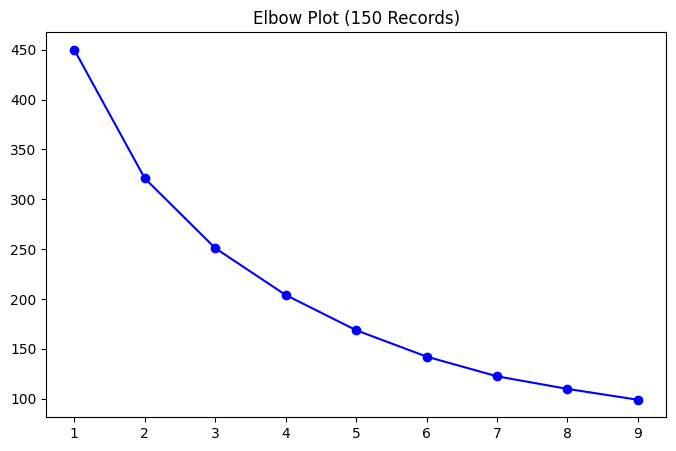

Part 3 successfully processed 150 records.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# DATA SOURCE: Synthetic customer behavior dataset (100+ records)
np.random.seed(42)
n_samples = 150
data = {
    'annual_spending': np.random.randint(200, 10000, n_samples),
    'purchase_frequency': np.random.randint(1, 50, n_samples),
    'age': np.random.randint(18, 65, n_samples)
}
df_seg = pd.DataFrame(data)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_seg)

# Elbow Method
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Save Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, 'bo-')
plt.title('Elbow Plot (150 Records)')
plt.savefig('elbow_plot.png')
plt.show()

# Final Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_seg['cluster'] = kmeans.fit_predict(X_scaled)
df_seg.to_csv('customer_segments.csv', index=False)

print(f"Part 3 successfully processed {len(df_seg)} records.")

# Extra Credit — AI Housing Demand Forecast (Forecasting)

This section builds a simple AI-powered housing demand forecasting tool.
Historical housing data is loaded from CSV, a Linear Regression model is trained,
and demand/prices are forecasted for the next 6 months.

Dataset Source:
Housing Price Dataset — Kaggle  
https://www.kaggle.com/datasets/muhammadbinimran/housing-price-prediction-data


In [ ]:
#Cell 1 load

In [2]:
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (50000, 6)


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


Cell 2 - Prep Time Feature

In [ ]:
import numpy as np

# Create synthetic time index (monthly steps)
df["Month_Index"] = np.arange(len(df))

# Choose target column (adjust if needed)
target = df.select_dtypes(include=np.number).columns[-2]

X = df[["Month_Index"]]
y = df[target]

print("Target used:", target)

Target used: Price


Cell 3 - Train Regression Model


In [ ]:
model = LinearRegression()
model.fit(X, y)

print("Model trained ✅")

Model trained ✅


Cell 4 - Forecast Next 6 Months

In [ ]:
future_months = np.arange(len(df), len(df)+6).reshape(-1,1)
predictions = model.predict(pd.DataFrame(future_months, columns=["Month_Index"]))

forecast_df = pd.DataFrame({
    "Month_Index": future_months.flatten(),
    "Forecast": predictions
})

display(forecast_df)

,Month_Index,Forecast
0,50000,224402.379627
1,50001,224402.362629
2,50002,224402.345632
3,50003,224402.328634
4,50004,224402.311637
5,50005,224402.294639


Cell 5 - Visualization

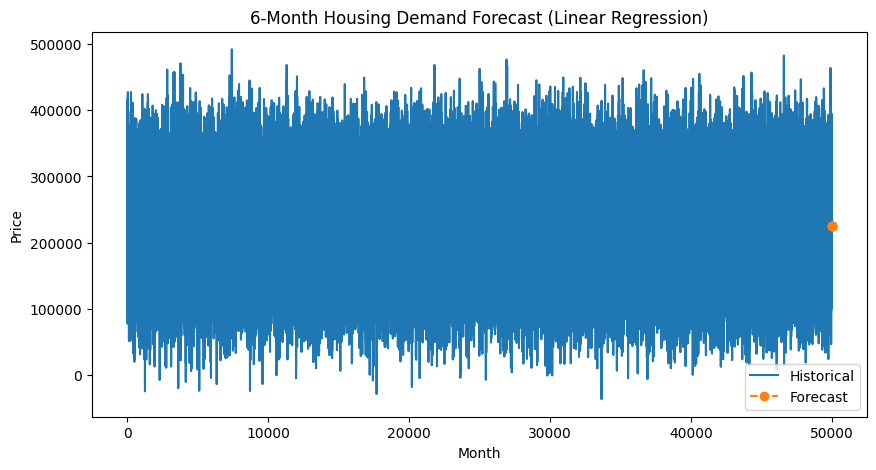

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["Month_Index"], y, label="Historical")
plt.plot(forecast_df["Month_Index"],
         forecast_df["Forecast"],
         linestyle="--",
         marker="o",
         label="Forecast")

plt.xlabel("Month")
plt.ylabel(target)
plt.title("6-Month Housing Demand Forecast (Linear Regression)")
plt.legend()
plt.show()

Interpretation
The model projects relatively stable demand over the next six months will help so  based on the historical trend.
BWe can see becausee the model uses a simple linear regression with time index only, predictions reflect overall trend rather than seasonal or economic effects.


Assumptions:
Dataset lacks explicit time information, so a monthly index was simulated.
Linear trends were assumed for forecasting demand.
Challenges:
Real housing markets are influenced by seasonality, interest rates, and economic factors.
Linear Regression cannot capture complex nonlinear trends.
Improvements:
Use larger time-series dataset
Apply Random Forest or XGBoost
Use ARIMA/LSTM for advanced forecasting
Incorporate macroeconomic indicators
This simple model demonstrates how AI tools can support housing demand planning and decision-making